In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import sys
sys.path.append('../')
from CEmulator.Emulator import GalaxyEmulator

Omegam = 0.3089 
OmegaL = 0.6911 
h      = 0.6774
sigma8 = 0.8159 
Omegab = 0.0486 
ns     = 0.9667
mnu    = 0.0
Omegan = mnu/93.14/h/h
Omegac = Omegam - Omegab - Omegan
w0     = -1
wa     = 0
redshift = 0.49

# Initialize the GalaxyEmulator
emu = GalaxyEmulator(verbose=False)
# Set cosmological parameters
emu.set_cosmos(
    Omegab=Omegab,
    Omegac=Omegac,
    H0=h*100,
    ns=ns,
    sigma8=sigma8,
    w=w0,
    wa=wa,
    mnu=mnu,
)
# Set HOD parameters (Zheng+2005 model)
print("\nSetting HOD parameters...")
param_dict = {'logMcut': 12.88504333, 
              'logM1': 13.89309923, 
              'sigma': 0.21378519, 
              'alpha': 0.99114528, 
              'kappa': 0.5, 
              'fic': 1.0}
emu.set_hod(
    model_name='Zheng07',
    logMcut=param_dict['logMcut'], 
    logM1=param_dict['logM1'], 
    sigma=param_dict['sigma'], 
    alpha=param_dict['alpha'], 
    kappa=param_dict['kappa']
)

# Compute galaxy properties at z=0.5
z = redshift
print(f"\nGalaxy properties at z={z}:")
print(f"  n_gal    = {emu.ngal(z):.4e} h^3/Mpc^3")
print(f"  f_sat    = {emu.f_sat(z):.3f}")
print(f"  M_eff    = {emu.M_eff(z):.3e} Msun/h")
print(f"  bias_gal = {emu.bias_gal(z):.3f}")



Setting HOD parameters...

Galaxy properties at z=0.49:
  n_gal    = 7.2573e-04 h^3/Mpc^3
  f_sat    = 0.176
  M_eff    = 3.024e+13 Msun/h
  bias_gal = 2.323


In [3]:
# Compute galaxy-matter correlation
r = np.logspace(-1, 2.5, 500)  # 0.1 to ~30 Mpc/h
z = 0.5

print(f"\nComputing galaxy-matter correlation at z={z}...")
%time Xigm = emu.Xigm(r, z)

print(f"Computing galaxy-galaxy correlation at z={z}...")
%time Xigg = emu.Xigg(r, z)

# Print some values
print(f"\nxi_gm(r=1 Mpc/h) = {Xigm[20]:.4f}")
print(f"xi_gg(r=1 Mpc/h) = {Xigg[20]:.4f}")


Computing galaxy-matter correlation at z=0.5...
CPU times: user 4.55 s, sys: 24.8 ms, total: 4.58 s
Wall time: 4.59 s
Computing galaxy-galaxy correlation at z=0.5...
CPU times: user 10.8 s, sys: 104 ms, total: 10.9 s
Wall time: 10.9 s

xi_gm(r=1 Mpc/h) = 2291.2279
xi_gg(r=1 Mpc/h) = 3094.5446


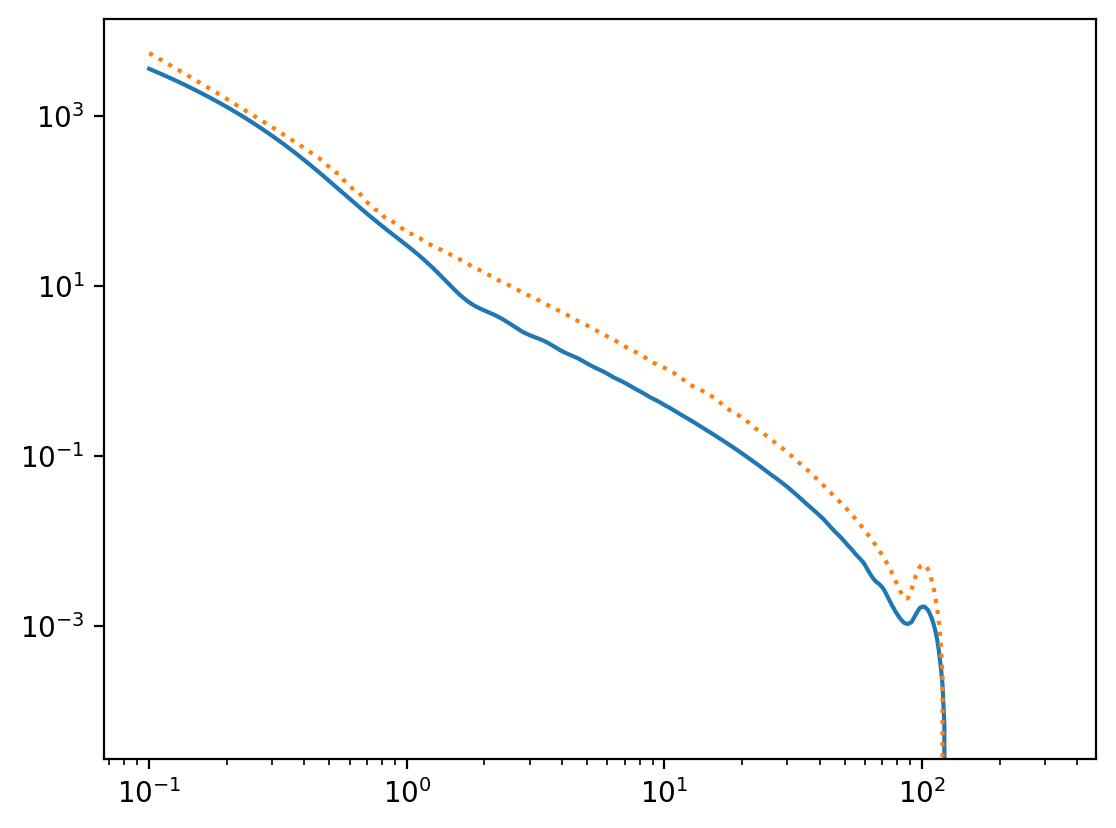

In [4]:
l1, = plt.plot(r, Xigm)
# plt.plot(r, -Xigm, ls='--', color=l1.get_color())

l2, = plt.plot(r, Xigg, ':')
# plt.plot(r, -Xigg, ls='--', color=l2.get_color())
plt.xscale('log')
plt.yscale('log')


In [5]:
rbins = np.logspace(-1, np.log10(50), 16) 
rmid  = (rbins[1:] + rbins[:-1])/2

wp_emu = emu.wp(rmid, z)

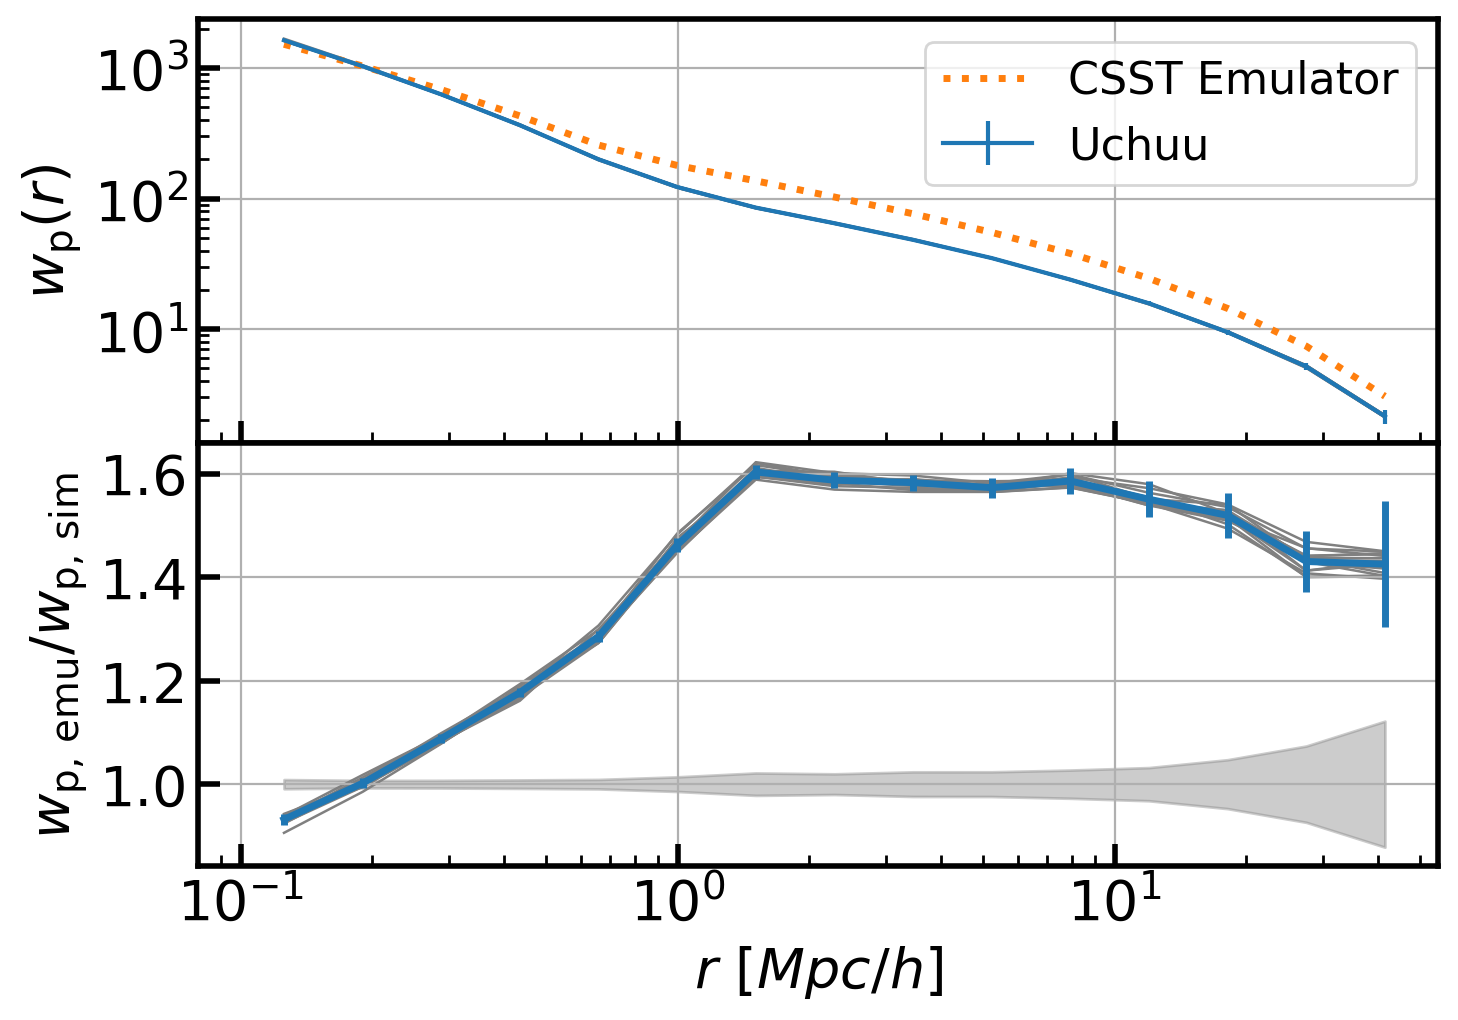

In [7]:
fdir = "/home/chenzhao/galaxy-assembly-bias/mocktest/"
wp_rlz = np.zeros((16, 15))
for iseed in range(16):
    wp_rlz[iseed] = np.load(fdir + "data/wp-galaxy-Uchuu1000-P18-1e12-Zheng07+fic-hod2-norsd-seed%d.npy"%(iseed))
std_wp  = np.std (wp_rlz, axis=0)
mean_wp = np.mean(wp_rlz, axis=0)
data_cv = np.zeros((100, 15))
for iseed in range(100):
    data_cv[iseed] = np.load(fdir + "data/Quijote/wp-galaxy-Quijote_HR-%d-1e12-Zheng07+fic-hod2-seed0.npy"%(iseed))
std_cv  = np.std (data_cv, axis=0)
mean_cv = np.mean(data_cv, axis=0)

cov_wp = np.load(fdir + "./data/cov-wp-galaxy-Uchuu1000-P18-1e12-Zheng07+fic-hod2-seed0.npy")
jack_wp = np.sqrt(np.diagonal(cov_wp))
with plt.style.context("presentation"):
    xlims = [8e-2, 55]
    gridp = plt.GridSpec(2,1,hspace=0)
    plt.subplot(gridp[0])
    for ii in range(wp_rlz.shape[0]):
        plt.plot(rmid, wp_rlz[ii], color='gray', lw=0.9, zorder=-1)
    plt.errorbar(rmid, mean_wp, jack_wp, lw=1.5, label='Uchuu')
    # plt.errorbar(rmid, mean_cv, std_cv, lw=1.0, label='Quijote') 
    plt.plot(rmid, wp_emu, ':', label='CSST Emulator')
    plt.legend(fontsize=16)
    plt.ylabel(r"$w_{\rm p}(r)$")
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(xlims)
    plt.grid('on')
    plt.gca().set_xticklabels([])
    plt.subplot(gridp[1])
    plt.errorbar(rmid, wp_emu/mean_wp, jack_wp/mean_wp)
    for ii in range(wp_rlz.shape[0]):
        plt.plot(rmid, wp_emu/wp_rlz[ii], color='gray', lw=0.9, zorder=-1) 
    plt.fill_between(rmid, 1-std_cv/mean_cv, 1+std_cv/mean_cv, color='gray', alpha=0.4) 
    plt.xscale('log')
    # plt.ylim([0.86, 1.14])
    plt.xlim(xlims)
    # plt.fill_between(xlims, 0.99, 1.01, color='gray', alpha=0.3)
    plt.grid('on')
    plt.xlabel(r"$r\ [Mpc/h]$")
    plt.ylabel(r"$w_{\rm p,\,emu}/w_{\rm p,\,sim}$")

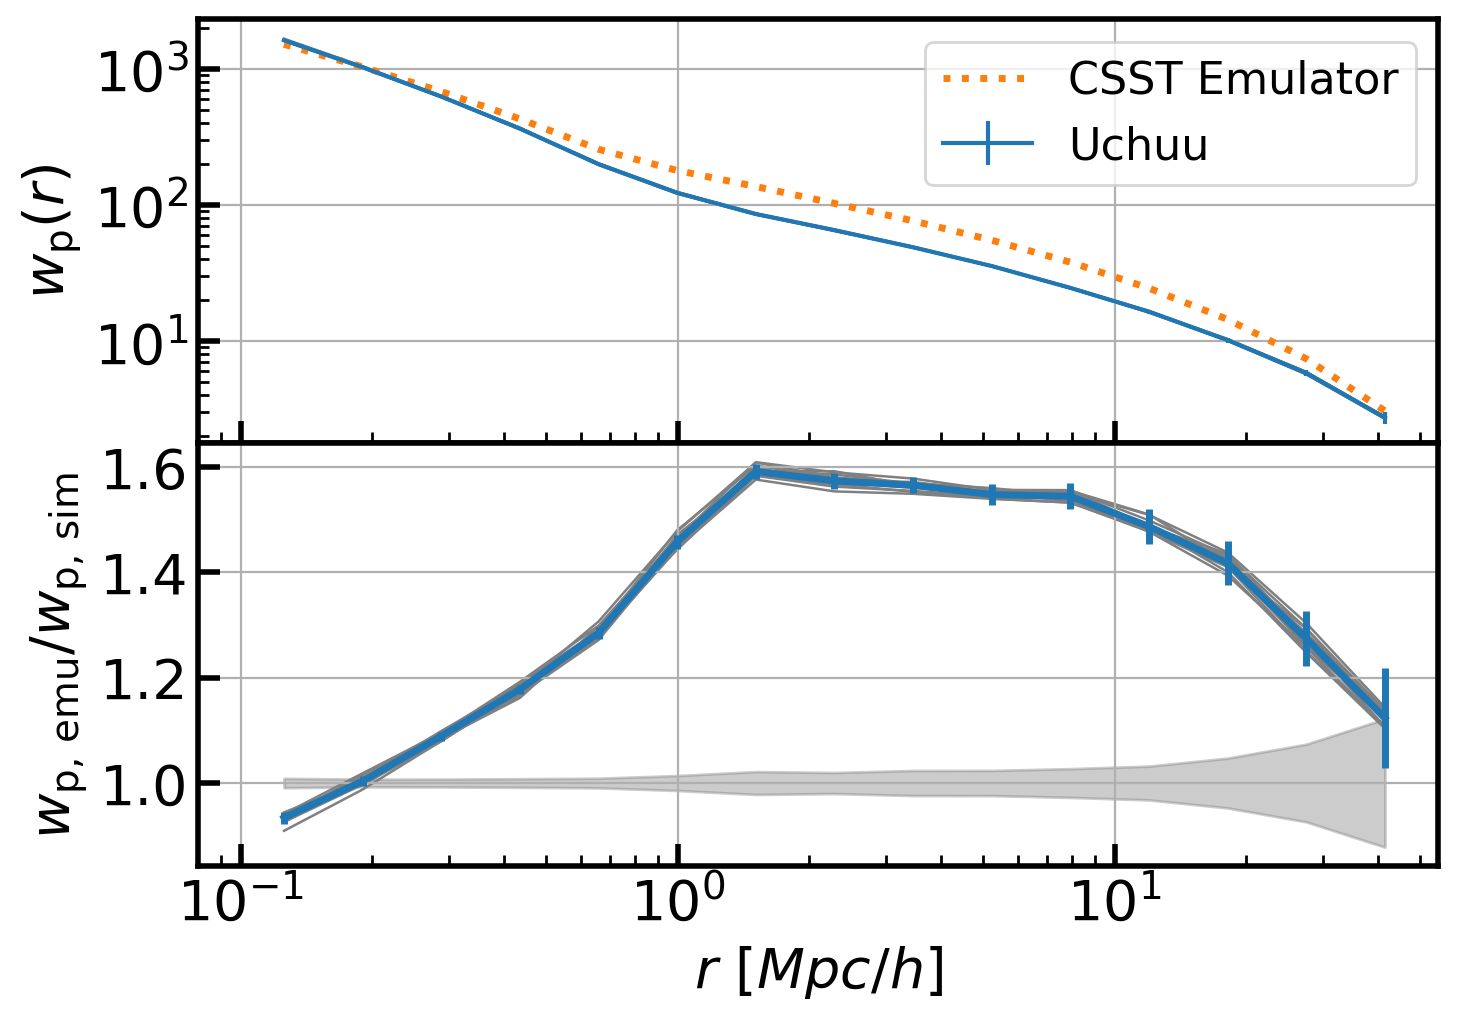

In [8]:
fdir = "/home/chenzhao/galaxy-assembly-bias/mocktest/"
wp_rlz = np.zeros((16, 15))
for iseed in range(16):
    wp_rlz[iseed] = np.load(fdir + "data/wp-galaxy-Uchuu1000-P18-1e12-Zheng07+fic-hod2-seed%d.npy"%(iseed))
std_wp  = np.std (wp_rlz, axis=0)
mean_wp = np.mean(wp_rlz, axis=0)
data_cv = np.zeros((100, 15))
for iseed in range(100):
    data_cv[iseed] = np.load(fdir + "data/Quijote/wp-galaxy-Quijote_HR-%d-1e12-Zheng07+fic-hod2-seed0.npy"%(iseed))
std_cv  = np.std (data_cv, axis=0)
mean_cv = np.mean(data_cv, axis=0)

cov_wp = np.load(fdir + "./data/cov-wp-galaxy-Uchuu1000-P18-1e12-Zheng07+fic-hod2-seed0.npy")
jack_wp = np.sqrt(np.diagonal(cov_wp))
with plt.style.context("presentation"):
    xlims = [8e-2, 55]
    gridp = plt.GridSpec(2,1,hspace=0)
    plt.subplot(gridp[0])
    for ii in range(wp_rlz.shape[0]):
        plt.plot(rmid, wp_rlz[ii], color='gray', lw=0.9, zorder=-1)
    plt.errorbar(rmid, mean_wp, jack_wp, lw=1.5, label='Uchuu')
    # plt.errorbar(rmid, mean_cv, std_cv, lw=1.0, label='Quijote') 
    plt.plot(rmid, wp_emu, ':', label='CSST Emulator')
    plt.legend(fontsize=16)
    plt.ylabel(r"$w_{\rm p}(r)$")
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim(xlims)
    plt.grid('on')
    plt.gca().set_xticklabels([])
    plt.subplot(gridp[1])
    plt.errorbar(rmid, wp_emu/mean_wp, jack_wp/mean_wp)
    for ii in range(wp_rlz.shape[0]):
        plt.plot(rmid, wp_emu/wp_rlz[ii], color='gray', lw=0.9, zorder=-1) 
    plt.fill_between(rmid, 1-std_cv/mean_cv, 1+std_cv/mean_cv, color='gray', alpha=0.4) 
    plt.xscale('log')
    # plt.ylim([0.86, 1.14])
    plt.xlim(xlims)
    # plt.fill_between(xlims, 0.99, 1.01, color='gray', alpha=0.3)
    plt.grid('on')
    plt.xlabel(r"$r\ [Mpc/h]$")
    plt.ylabel(r"$w_{\rm p,\,emu}/w_{\rm p,\,sim}$")